 1. Setup Awal

In [1]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Clustering - Membuat Dataset

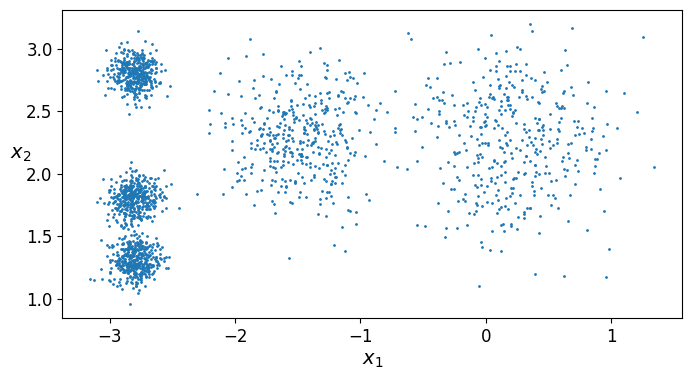

In [2]:
from sklearn.datasets import make_blobs

# Membuat data dummy untuk clustering
blob_centers = np.array(
    [[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
     [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

# Fungsi untuk plot cluster
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

3. K-Means - Pelatihan dan Visualisasi

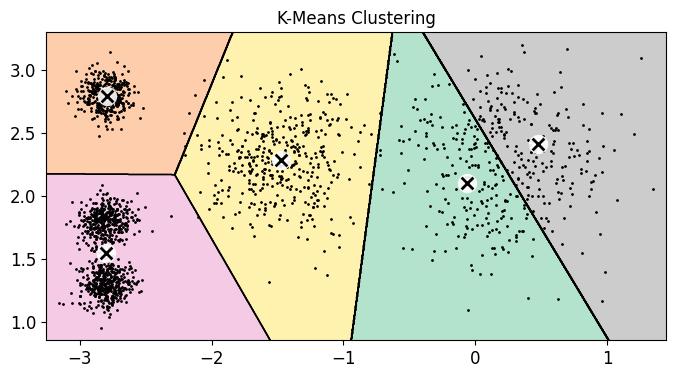

In [3]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
y_pred = kmeans.fit_predict(X)

# Fungsi untuk plot decision boundaries K-Means (Voronoi)
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    # ... (kode helper untuk plotting)
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

# Plot hasil K-Means
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.title("K-Means Clustering")
plt.show()

4. K-Means - Menemukan Jumlah Cluster Optimal

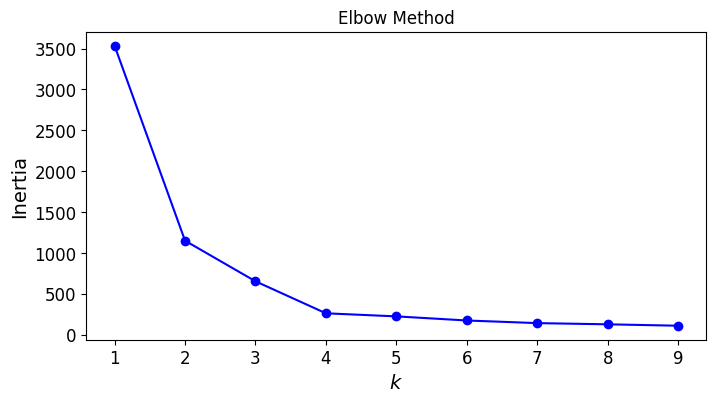

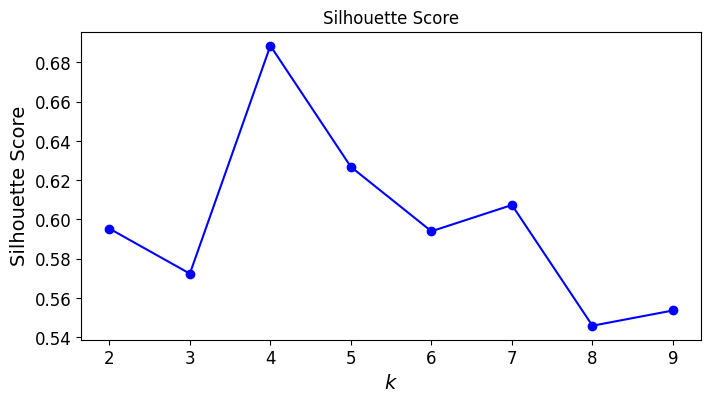

In [4]:
from sklearn.metrics import silhouette_score

# 1. Elbow Method menggunakan inertia
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# 2. Silhouette Score
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]] # Mulai dari k=2

plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

 5. DBSCAN

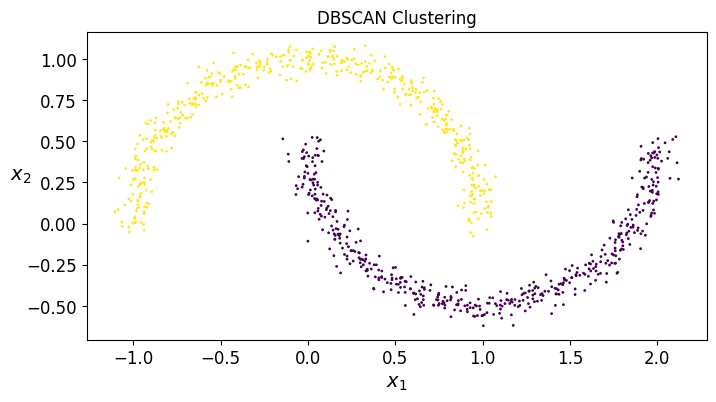

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Membuat dataset moons yang tidak bisa dipisahkan dengan K-Means
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Menggunakan DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)

# Plot hasil DBSCAN
plt.figure(figsize=(8, 4))
plot_clusters(X, dbscan.labels_)
plt.title("DBSCAN Clustering")
plt.show()

 6. Gaussian Mixture Models (GMM)

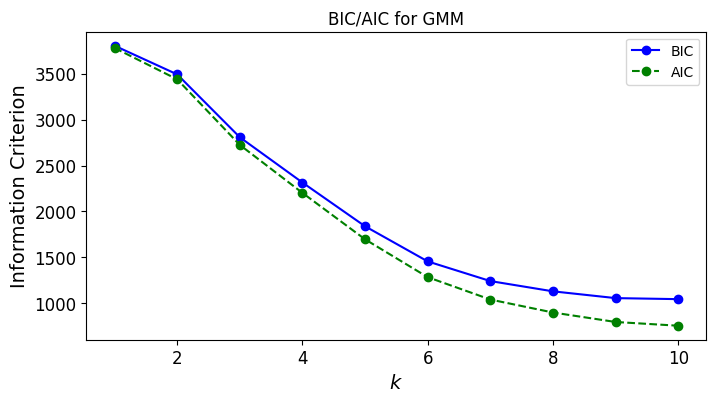

In [6]:
from sklearn.mixture import GaussianMixture

# Menggunakan GMM pada data blobs sebelumnya
gm = GaussianMixture(n_components=5, n_init=10, random_state=42)
gm.fit(X)

# Membandingkan BIC dan AIC untuk menemukan jumlah cluster optimal
gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]

bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

# Plot BIC dan AIC
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.legend()
plt.title("BIC/AIC for GMM")
plt.show()

Penjelasan Kode
Bagian 1 & 2. Setup dan Membuat Dataset: Bagian ini melakukan persiapan standar dan membuat dataset dummy menggunakan make_blobs. Dataset ini sengaja dibuat memiliki 5 kelompok (cluster) yang jelas agar kita bisa dengan mudah mengevaluasi hasil dari algoritma clustering.

Bagian 3. K-Means - Pelatihan dan Visualisasi:

K-Means adalah algoritma clustering yang paling umum. Tujuannya adalah untuk mempartisi data ke dalam K cluster yang telah ditentukan. Ia bekerja dengan cara:

Memilih K titik acak sebagai pusat cluster awal (centroids).

Mengelompokkan setiap titik data ke centroid terdekat.

Menghitung ulang posisi centroid berdasarkan rata-rata dari semua titik data di clusternya.

Mengulangi langkah 2 dan 3 sampai posisi centroid tidak berubah lagi.

Visualisasi: Plot yang dihasilkan menunjukkan decision boundaries yang disebut Voronoi Tessellation. Setiap wilayah berwarna adalah "milik" satu centroid; semua titik di dalam wilayah tersebut lebih dekat ke centroid itu daripada ke centroid lainnya.

Bagian 4. Menemukan Jumlah Cluster Optimal untuk K-Means: Salah satu tantangan K-Means adalah kita harus menentukan jumlah cluster (K) di awal. Bagian ini menunjukkan dua metode untuk membantu kita memilih K yang tepat:

Elbow Method: Metode ini mengukur inertia, yaitu total jarak kuadrat dari setiap titik ke centroid clusternya. Kita membuat plot inertia untuk berbagai nilai K. "Siku" (elbow) pada grafik (titik di mana penurunan inertia mulai melandai) seringkali dianggap sebagai nilai K yang baik.

Silhouette Score: Ini adalah metrik yang lebih baik. Skor ini mengukur seberapa mirip sebuah titik data dengan clusternya sendiri dibandingkan dengan cluster lain. Nilai skor berkisar dari -1 hingga 1. Nilai mendekati +1 berarti titik tersebut sangat pas di clusternya. Nilai K yang memberikan silhouette score tertinggi biasanya adalah pilihan terbaik.

Bagian 5. DBSCAN:

K-Means kesulitan menemukan cluster yang bentuknya tidak bulat (non-globular). DBSCAN (Density-Based Spatial Clustering of Applications with Noise) adalah solusinya.

Algoritma ini bekerja berdasarkan kepadatan. Ia mengelompokkan titik-titik yang berdekatan dan menandai titik yang berada di area berkepadatan rendah sebagai noise atau outlier.

eps: Jarak maksimum untuk sebuah titik dianggap sebagai tetangga.

min_samples: Jumlah minimum titik dalam sebuah lingkungan eps agar titik tersebut dianggap sebagai titik inti (core point).

Seperti yang terlihat pada plot, DBSCAN berhasil mengidentifikasi dua cluster berbentuk bulan sabit, tugas yang tidak bisa dilakukan K-Means.

Bagian 6. Gaussian Mixture Models (GMM):

GMM adalah algoritma clustering yang lebih fleksibel daripada K-Means. Ia bekerja dengan asumsi bahwa data berasal dari campuran beberapa distribusi Gaussian (berbentuk elips/lonjong) dengan parameter yang tidak diketahui.

Soft Clustering: Berbeda dengan K-Means yang memberikan label pasti (hard clustering), GMM memberikan probabilitas untuk setiap titik data menjadi anggota dari setiap cluster.

BIC/AIC: Untuk menemukan jumlah cluster yang optimal, GMM menggunakan kriteria informasi seperti BIC (Bayesian Information Criterion) dan AIC (Akaike Information Criterion). Kriteria ini mencoba menyeimbangkan antara seberapa baik model cocok dengan data dengan kompleksitas model itu sendiri. Model terbaik adalah yang memiliki skor BIC/AIC terendah.